# **Multimodal Bird Species Classification**
**Student:** Gevorg Alaverdyan


## **1. Abstract**
This project developed a multimodal bird species classifier that combines visual and auditory data. The CUB-200-2011 dataset (200 bird species) was used for images. Since no public audio dataset exists for these species, a spectrogram dataset of 9,270 samples across 199 species was independently collected from Xeno-Canto and eBird, preprocessed, labeled, and published publicly to enable full reproducibility, addressing a key limitation of prior work that relied on private audio data. Dual-stream ResNet-50 models under three fusion strategies were trained: early fusion with channel-wise input concatenation, middle fusion with embedding concatenation, and late fusion with score summation. All multimodal models outperform both unimodal baselines (image-only: 70.57%, spectrogram-only: 38.33%), with late fusion achieving the best Top-1 test accuracy of 83.16%. These results are consistent with the findings of Naranchimeg et al. (2018) [5], confirming that fusing independently learned modality-specific features at the decision level is the most effective strategy.

## **2. Introduction**

Precisely identifying bird species is a challenging task in the ecological domain because species often share overlapping visual features and are frequently obscured by natural habitats. When visual cues are obscured by greenery or dim illumination, relying only on image data is not enough. By combining visual and distinctive auditory inputs, this project aims to improve classification accuracy and contribute to biodiversity preservation through more reliable ecosystem monitoring.

Image-based methods such as Part-based R-CNNs [1] and Pose-Normalized CNNs [2] achieve strong results on fine-grained visual recognition, while audio-based methods using CNNs on spectrograms [3, 4] have proven effective for bird sound classification. However, few studies combine both modalities within a unified framework.

Naranchimeg et al. [5] proposed a CNN-based multimodal approach for bird classification, comparing early, middle, and late fusion strategies using CaffeNet on CUB-200-2011 images and a privately collected audio dataset. Their best model (late fusion with two-stage fine-tuning) reached 78.9% accuracy on 194 species. However, their audio dataset was never published, making the work impossible to reproduce or build upon directly.

This project builds upon that work with three key contributions:

1. A publicly available audio-spectrogram dataset. Audio recordings for 199 of the 200 CUB-200-2011 species were independently collected from Xeno-Canto and eBird, converted to spectrograms, filtered, cleaned, labeled, and published as a public Kaggle dataset. This is nearly twice the size of the original study's private collection (9,270 vs. 4,807 spectrograms) and covers 5 more species (199 vs. 194), with 192 species having the recommended minimum of 10 recordings (vs. 178 in the original). This makes the entire pipeline fully reproducible.
2. A modern backbone architecture. ResNet-50 pretrained on ImageNet [7] is used instead of the older CaffeNet, providing deeper layers and residual connections that avoid vanishing gradient issues.
3. The original study used a train/test split, but my project uses a proper train/validation/test split ensuring that model selection is performed on validation data and final metrics are reported on a fully held-out test set.

The same three fusion strategies (early, middle, late) are compared, and the results confirm that late fusion remains the best approach, achieving 83.16% Top-1 accuracy on 199 bird species.

![Image](https://drive.google.com/uc?export=view&id=1pP3w_hSZXXjrY24KMhL6Xlnh-MwwV9S_)

*Figure 1: Matching pair dataset sample. On the left is an image of a Black footed Albatros, on the right is the specie's audio spectrogram.*

## **3 Methodology**

### 3.1 Overview

The system takes two inputs per sample: a bird photograph and a spectrogram of the same species' vocalization. Both are processed as 224x224 RGB images by ResNet-50 backbones pretrained on ImageNet. Three fusion strategies determine how and where the two modality streams are combined.

### 3.2 Audio Dataset Construction
A central contribution of this project is the construction and publication of a spectrogram dataset aligned with CUB-200-2011. The original study by Naranchimeg et al. [5] collected audio recordings privately and never published the dataset, making their results impossible to reproduce. To address this, the following pipeline was developed:

1. **Collection:** Audio recordings were scraped from Xeno-Canto and eBird for each of the 200 CUB-200-2011 species. The goal was to collect at least 10 recordings per species to ensure sufficient variation for training.
2. **Filtering:** Recordings were filtered to retain only those with clear vocalizations. Silence trimming removed low-energy segments, and frequency filtering isolated the 0-10 kHz range where bird vocalizations are most distinct.
3. **Spectrogram conversion:** Each audio clip was converted into a 224x224 RGB spectrogram using the Short-Time Fourier Transform (STFT) with a Hanning window (size 512, 50% overlap).
4. **Labeling and quality control:** Each spectrogram was labeled with its corresponding CUB-200-2011 class ID. A subset of recordings was manually inspected to verify label correctness and remove heavily corrupted samples.
5. **Publication:** The final dataset (9,270 spectrograms, 199 species) was published publicly on Kaggle to enable full reproducibility: https://www.kaggle.com/datasets/gevorgalaverdyan/bird-species-audio-spectrograms-cub-200-aligned

The resulting dataset is nearly twice the size of the original study's private collection (9,270 vs. 4,807) and covers 5 more species (199 vs. 194), with 192 species meeting the ≥10 recordings threshold compared to 178 in the original.

### 3.3 Preprocessing

**Images** are resized to 256x256 and randomly cropped to 224x224 during training, with horizontal flipping and color jitter for augmentation. At test time, images are resized directly to 224x224. All images are normalized with ImageNet statistics.

**Spectrograms** undergo a silence-cropping step (`CropSilence`) that removes low-energy background columns before resizing. This ensures the CNN sees actual vocalization content rather than empty padding. No horizontal flipping or color jitter is applied to spectrograms, since flipping would reverse the time axis and color jitter would distort the encoded frequency-amplitude relationship.

### 3.4 Fusion Strategies

**Early fusion (Net1):** The image and spectrogram tensors are concatenated along the channel dimension into a [B, 6, 224, 224] volume. A single ResNet-50 with its first convolutional layer modified from 3 to 6 input channels processes the combined input. The pretrained weights are duplicated across both channel groups to initialize the new convolution.

<div>
<img src="https://drive.google.com/uc?export=view&id=1a3YjIfOR4oqt3I67q_Fa4mB4WjOOth0u" width="500"/>
</div>

*Figure 2: Early fusion architecture. The image and spectrogram are concatenated along the channel dimension and processed by a single modified ResNet-50.*

**Middle fusion (Net2):** Two separate ResNet-50 backbones each extract a 2048-dimensional feature vector from their respective modality. The two vectors are concatenated into a 4096-dimensional representation, which is passed through a fully connected classifier head (4096 → 1024 → num_classes) with ReLU activation and dropout.

<div>
<img src="https://drive.google.com/uc?export=view&id=1aQy9uuz7hrm28wwSxCWSGNEp1F5bqRET" width="500"/>
</div>

*Figure 3: Middle fusion architecture. Two ResNet-50 backbones extract embeddings independently, which are concatenated and classified by a shared head.*

**Late fusion (Net3 aka Best Model):** Two independent ResNet-50 models each produce class-score vectors (logits) of dimension [B, num_classes]. The final prediction is the element-wise summation of the two score vectors. This is the simplest fusion approach, each stream learns to classify independently, and their decisions are combined at the output level.

<div>
<img src="https://drive.google.com/uc?export=view&id=1v5dudCtMGO5sGts0Ar9Difc6N8YbQABM" width="500"/>
</div>

*Figure 4: Late fusion architecture. Two independent ResNet-50 models produce separate class scores, which are summed at the output level.*

### 3.5 Unimodal Baselines

To validate that multimodal fusion improves performance, two single-stream ResNet-50 baselines are also trained: one on images only and one on spectrograms only. These use the same optimizer and learning rate as the multimodal models but are trained for 15 epochs instead of 30, since single-modality models converge faster on their respective domains.


## **4 Experimental Setup**

### 4.1 Datasets

**CUB-200-2011** [6] contains 11,788 images of 200 bird species. The standard train/test split (5,994 train / 5,794 test) is used. One species lacked audio data and was excluded, leaving 199 classes and 11,730 images.

**Spectrogram dataset** was independently collected and published as part of this project (see cell above). The dataset contains 9,270 spectrograms across 199 species, split 50/50 into train (4,635) and test (4,635) using stratified sampling. It is publicly available on Kaggle at: https://www.kaggle.com/datasets/gevorgalaverdyan/bird-species-audio-spectrograms-cub-200-aligned

The table below compares this dataset with the one from the original study:

| Metric | Original study [5] | Mine |
|--------|-------------------|------|
| Total spectrograms | 4,807 | 9,270 |
| Species covered | 194 / 200 | 199 / 200 |
| Species with ≥10 recordings | 178 | 192 |
| Species with <10 recordings | 19 | 7 |
| Species with 0 recordings | 3 | 1 |
| Spectrograms per species (min / mean / max) | - | 2 / 52 / 142 |
| Spectrogram resolution | 227x227 | 224x224 |
| Format | Color (JPEG via HDF5) | RGB PNG |
| **Publicly available** | **No** | **Yes** |

The dataset is nearly twice as large as the original (9,270 vs. 4,807), covers 5 more species, and is critically the first publicly available audio-spectrogram dataset aligned with CUB-200-2011.

### 4.2 Data Splits

To avoid data leakage and ensure proper model selection:

| Split | CUB Images | Spectrograms | Purpose |
|-------|-----------|-------------|----------|
| Train | 4,795 (80% of CUB train) | 4,635 (50% of specs) | Model training |
| Validation | 1,199 (20% of CUB train) | 4,635 (same as train) | Checkpoint selection & LR scheduling |
| Test | 5,736 (CUB test split) | 4,635 (50% of specs) | Final evaluation only |

The validation split is carved from the CUB training set (80/20). Best checkpoints are selected based on validation accuracy. (the test set is used only for final reported metrics)

*Note on spectrogram overlap: The validation set reuses the training spectrograms because the audio dataset is substantially smaller than the image dataset (9,270 vs. 11,730). Splitting it further would leave too few spectrograms per species for meaningful training. Since each CUB image is paired with a randomly selected same-class spectrogram, the validation signal is still driven by the unseen CUB images. Importantly, the test spectrograms are fully separate, so all final reported metrics are free of leakage.*

### 4.3 Hyperparameters

The hyperparameters below were adopted from the original study [5] and held fixed throughout all experiments:

| Parameter | Value |
|-----------|-------|
| Backbone | ResNet-50 (ImageNet pretrained) |
| Optimizer | Adam (lr=1e-4, weight_decay=1e-4) |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=3) |
| Batch size | 16 |
| Epochs | 30 (multimodal), 15 (unimodal) |
| Loss | CrossEntropyLoss |
| Seed | 42 |

## **5 Experimental Results**

### 5.1 Setup and Data Loading
The following cells download the datasets, prepare the data splits, and define the model architectures and training utilities.


In [ ]:
# Download pretrained checkpoints from Google Drive (optional, skip to train from scratch)
import gdown

folder_url = "https://drive.google.com/drive/u/3/folders/1_bJn2LK0XTU8wHhkvMbwkuLdZ11g_H-l"
gdown.download_folder(folder_url, quiet=False, use_cookies=False)

Retrieving folder contents


Processing file 1iU0aZy6YNZHWI2Vrgau3z9X-hbYAyMqx early_fusion_best.pth
Processing file 1T3rGaLV5zuZfkP9FNkWM-FRmyw6SH_lR late_fusion_best.pth
Processing file 1imQeEppiWvW3nTt7RqZp0cDb6v6L2S2X middle_fusion_best.pth
Processing file 1-0a9ALpdNa9KpDhrPe1aDlhJGkU-Lz7l unimodal_image_best.pth
Processing file 1ZPz1FHx1B3c73pHn6cLZZSqQj2kcut0m unimodal_spec_best.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1iU0aZy6YNZHWI2Vrgau3z9X-hbYAyMqx
From (redirected): https://drive.google.com/uc?id=1iU0aZy6YNZHWI2Vrgau3z9X-hbYAyMqx&confirm=t&uuid=f5e74c04-5955-4018-9904-0ff7b04501b7
To: /content/models/early_fusion_best.pth
100%|██████████| 96.0M/96.0M [00:00<00:00, 107MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1T3rGaLV5zuZfkP9FNkWM-FRmyw6SH_lR
From (redirected): https://drive.google.com/uc?id=1T3rGaLV5zuZfkP9FNkWM-FRmyw6SH_lR&confirm=t&uuid=98cf9856-c3e3-45d0-ab7f-fc46a87ce7fc
To: /content/models/late_fusion_best.pth
100%|██████████| 192M/192M [00:02<00:00, 69.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1imQeEppiWvW3nTt7RqZp0cDb6v6L2S2X
From (redirected): https://drive.google.com/uc?id=1imQeEppiWvW3nTt7RqZp0cDb6v6L2S2X&confirm=t&uuid=183d3b96-e923-4118-b442-a4651f8da867
To: /conte

['/content/models/early_fusion_best.pth',
 '/content/models/late_fusion_best.pth',
 '/content/models/middle_fusion_best.pth',
 '/content/models/unimodal_image_best.pth',
 '/content/models/unimodal_spec_best.pth']

In [ ]:
import os
import random

import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


In [ ]:
import kagglehub

# https://www.kaggle.com/datasets/wenewone/cub2002011
bird_images_path = kagglehub.dataset_download("wenewone/cub2002011")

# https://www.kaggle.com/datasets/gevorgalaverdyan/bird-species-audio-spectrograms-cub-200-aligned
bird_spectrograms_path = kagglehub.dataset_download(
    "gevorgalaverdyan/bird-species-audio-spectrograms-cub-200-aligned"
)

print("Images path      :", bird_images_path)
print("Spectrograms path:", bird_spectrograms_path)


Using Colab cache for faster access to the 'cub2002011' dataset.
Using Colab cache for faster access to the 'bird-species-audio-spectrograms-cub-200-aligned' dataset.
Images path      : /kaggle/input/cub2002011
Spectrograms path: /kaggle/input/bird-species-audio-spectrograms-cub-200-aligned


In [ ]:
CUB_ROOT = Path(f"{bird_images_path}/CUB_200_2011")
SPEC_ROOT = Path(bird_spectrograms_path)

for f in ["images.txt", "image_class_labels.txt", "train_test_split.txt", "classes.txt"]:
    print(f"CUB  {f}: {'OK' if (CUB_ROOT / f).exists() else 'MISSING'}")
print(f"SPEC metadata.csv: {'OK' if (SPEC_ROOT / 'metadata.csv').exists() else 'MISSING'}")
print(f"SPEC spectrograms/: {'OK' if (SPEC_ROOT / 'spectrograms').exists() else 'MISSING'}")


CUB  images.txt: OK
CUB  image_class_labels.txt: OK
CUB  train_test_split.txt: OK
CUB  classes.txt: OK
SPEC metadata.csv: OK
SPEC spectrograms/: OK


In [ ]:
df_images = pd.read_csv(
    CUB_ROOT / "images.txt", sep=" ", header=None, names=["image_id", "file_path"]
)
df_labels = pd.read_csv(
    CUB_ROOT / "image_class_labels.txt", sep=" ", header=None, names=["image_id", "class_id"]
)
df_split = pd.read_csv(
    CUB_ROOT / "train_test_split.txt", sep=" ", header=None, names=["image_id", "is_train"]
)
df_classes = pd.read_csv(
    CUB_ROOT / "classes.txt", sep=" ", header=None, names=["class_id", "class_name"]
)

cub_df = (
    df_images
    .merge(df_labels, on="image_id")
    .merge(df_split, on="image_id")
    .merge(df_classes, on="class_id")
)

print("CUB shape   :", cub_df.shape)
print("Classes     :", cub_df["class_id"].nunique())
print("Train / Test:", cub_df["is_train"].sum(), "/", (cub_df["is_train"] == 0).sum())
cub_df.head(3)


CUB shape   : (11788, 5)
Classes     : 200
Train / Test: 5994 / 5794


,image_id,file_path,class_id,is_train,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,001.Black_footed_Albatross


In [ ]:
spec_meta = pd.read_csv(SPEC_ROOT / "metadata.csv")
print("Spec shape  :", spec_meta.shape)
print("Classes     :", spec_meta["class_id"].nunique())
print("Columns     :", spec_meta.columns.tolist())
spec_meta.head(3)


Spec shape  : (9270, 5)
Classes     : 199
Columns     : ['file_path', 'class_id', 'species', 'image_id', 'segment_number']


,file_path,class_id,species,image_id,segment_number
0,001.Black_footed_Albatross/Black_footed_Albatr...,1,Black footed Albatross,Black_footed_Albatross_116349,0
1,001.Black_footed_Albatross/Black_footed_Albatr...,1,Black footed Albatross,Black_footed_Albatross_116349,1
2,001.Black_footed_Albatross/Black_footed_Albatr...,1,Black footed Albatross,Black_footed_Albatross_116349,2


### **Spectrogram Dataset distribution**

* Total spectrograms : 9270
* Species            : 199
* Min / Mean / Max   : 3 / 46.6 / 149
* Species with ≥10   : 192
* Species with <10   : 7

![spectrogram distribution](https://drive.google.com/uc?export=view&id=1nht0NiVQkVo2Z_8mV_-bOwubwULUTRgC)

In [ ]:
cub_df["class_id"] = cub_df["class_id"].astype(int)
spec_meta["class_id"] = spec_meta["class_id"].astype(int)

cub_classes = set(cub_df["class_id"].unique())
spec_classes = set(spec_meta["class_id"].unique())
shared = sorted(cub_classes & spec_classes)

print(f"CUB classes         : {len(cub_classes)}")
print(f"Spectrogram classes : {len(spec_classes)}")
print(f"Shared classes      : {len(shared)}")
print(f"Dropped             : {len(cub_classes - spec_classes)} class(es) missing audio")

cub_df = cub_df[cub_df["class_id"].isin(shared)].reset_index(drop=True)
spec_meta = spec_meta[spec_meta["class_id"].isin(shared)].reset_index(drop=True)

class_to_label = {cid: idx for idx, cid in enumerate(shared)}
NUM_CLASSES = len(shared)

cub_df["label"] = cub_df["class_id"].map(class_to_label)
spec_meta["label"] = spec_meta["class_id"].map(class_to_label)

# Split spectrograms 50/50 per class (stratified)
spec_train_meta, spec_test_meta = train_test_split(
    spec_meta, test_size=0.5, random_state=SEED, stratify=spec_meta["label"]
)
spec_train_meta = spec_train_meta.reset_index(drop=True)
spec_test_meta = spec_test_meta.reset_index(drop=True)

print(f"\nNUM_CLASSES = {NUM_CLASSES}  (labels 0 – {NUM_CLASSES - 1})")
print(f"CUB rows    : {len(cub_df)}")
print(f"Spec rows   : {len(spec_meta)} -> train {len(spec_train_meta)}, test {len(spec_test_meta)}")

assert set(cub_df["label"]).issubset(set(spec_train_meta["label"]))
assert set(cub_df["label"]).issubset(set(spec_test_meta["label"]))
print("All CUB classes have spectrograms in both splits")


CUB classes         : 200
Spectrogram classes : 199
Shared classes      : 199
Dropped             : 1 class(es) missing audio

NUM_CLASSES = 199  (labels 0 – 198)
CUB rows    : 11730
Spec rows   : 9270 -> train 4635, test 4635
All CUB classes have spectrograms in both splits


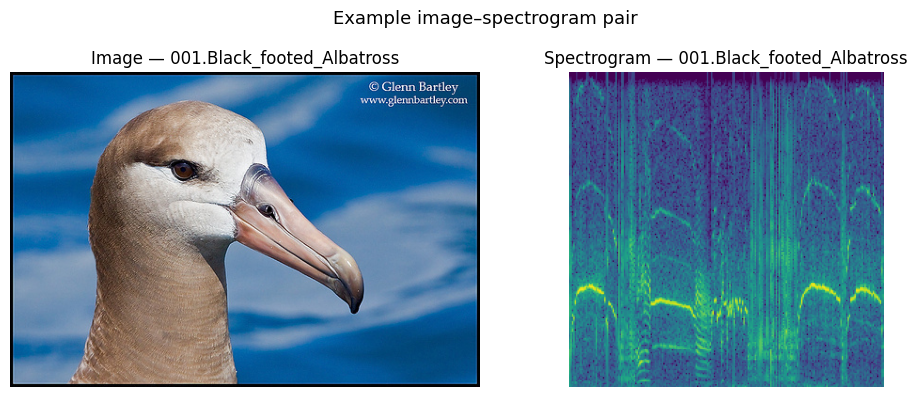

In [ ]:
sample = cub_df.iloc[0]
img_path = CUB_ROOT / "images" / sample["file_path"]
spec_row = spec_meta[spec_meta["label"] == sample["label"]].iloc[0]
spec_path = SPEC_ROOT / "spectrograms" / spec_row["file_path"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(Image.open(img_path))
axes[0].set_title(f"Image — {sample['class_name']}")
axes[0].axis("off")
axes[1].imshow(Image.open(spec_path))
axes[1].set_title(f"Spectrogram — {sample['class_name']}")
axes[1].axis("off")
plt.suptitle("Example image–spectrogram pair", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class CropSilence:
    """Crop a spectrogram image to its active (non-silent) region.

    Identifies columns whose pixel intensity deviates from the background
    by more than `threshold` and crops the image to that horizontal span.
    This removes silent padding so the subsequent Resize fills the frame
    with actual vocalization content.

    Parameters
    ----------
    threshold : int
        Minimum absolute deviation from estimated background to count as active.
    min_content_frac : float
        If active columns are fewer than this fraction of total width,
        return the image uncropped (safety fallback).

    Returns
    -------
    PIL.Image
        Cropped image, or original if too little content was detected.

    Example
    -------
    >>> transform = CropSilence(threshold=15)
    >>> cropped = transform(Image.open("spectrogram.png"))
    """

    def __init__(self, threshold=15, min_content_frac=0.1):
        self.threshold = threshold
        self.min_content_frac = min_content_frac

    def __call__(self, img):
        arr = np.array(img.convert("L"))
        bg = np.percentile(arr, 5)
        active = np.where(
            (np.abs(arr.astype(float) - bg) > self.threshold).any(axis=0)
        )[0]
        if len(active) < arr.shape[1] * self.min_content_frac:
            return img
        margin = 4
        x1 = max(0, active[0] - margin)
        x2 = min(arr.shape[1], active[-1] + margin)
        return img.crop((x1, 0, x2, img.height))


# Image transforms: standard augmentation, NO CropSilence
img_train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

img_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Spectrogram transforms: CropSilence, no flip or color jitter
spec_train_transform = transforms.Compose([
    CropSilence(),
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

spec_val_transform = transforms.Compose([
    CropSilence(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms defined")


Transforms defined


In [ ]:
class MultimodalBirdDataset(Dataset):
    """Dataset that pairs each CUB bird image with a same-species spectrogram.

    For each CUB image, a spectrogram of the same class is selected.
    During training, the spectrogram is chosen randomly for augmentation.
    During evaluation, a deterministic mapping (cycling) is used for
    reproducible results.

    Parameters
    ----------
    cub_df : pd.DataFrame
        CUB metadata with columns 'file_path' and 'label'.
    spec_df : pd.DataFrame
        Spectrogram metadata with columns 'file_path' and 'label'.
    cub_root : str or Path
        Root directory of CUB-200-2011 dataset.
    spec_root : str or Path
        Root directory of spectrogram dataset.
    img_transform : torchvision.transforms.Compose, optional
        Transform pipeline for bird images.
    spec_transform : torchvision.transforms.Compose, optional
        Transform pipeline for spectrograms.
    deterministic : bool
        If True, uses deterministic spectrogram pairing (for evaluation).

    Returns
    -------
    tuple of (torch.Tensor, torch.Tensor, int)
        (image, spectrogram, label)

    Example
    -------
    >>> ds = MultimodalBirdDataset(cub_train, spec_train, CUB_ROOT, SPEC_ROOT)
    >>> img, spec, label = ds[0]
    """

    def __init__(self, cub_df, spec_df, cub_root, spec_root,
                 img_transform=None, spec_transform=None, deterministic=False):
        self.cub_df = cub_df.reset_index(drop=True)
        self.cub_root = Path(cub_root)
        self.spec_root = Path(spec_root)
        self.img_transform = img_transform
        self.spec_transform = spec_transform
        self.deterministic = deterministic
        self.spec_by_label = (
            spec_df.groupby("label")["file_path"].apply(list).to_dict()
        )

    def __len__(self):
        return len(self.cub_df)

    def __getitem__(self, idx):
        row = self.cub_df.iloc[idx]
        label = int(row["label"])

        img = Image.open(self.cub_root / "images" / row["file_path"]).convert("RGB")
        if self.img_transform:
            img = self.img_transform(img)

        specs_list = self.spec_by_label[label]
        if self.deterministic:
            spec_file = specs_list[idx % len(specs_list)]
        else:
            spec_file = random.choice(specs_list)
        spec = Image.open(self.spec_root / "spectrograms" / spec_file).convert("RGB")
        if self.spec_transform:
            spec = self.spec_transform(spec)

        return img, spec, label


BATCH_SIZE = 16

# 80/20 stratified split of CUB train for train/val
cub_train = cub_df[cub_df["is_train"] == 1].reset_index(drop=True)
train_idx, val_idx = train_test_split(
    range(len(cub_train)), test_size=0.2, random_state=SEED,
    stratify=cub_train["label"]
)

train_ds = MultimodalBirdDataset(
    cub_train.iloc[train_idx], spec_train_meta, CUB_ROOT, SPEC_ROOT,
    img_transform=img_train_transform, spec_transform=spec_train_transform,
    deterministic=False,
)
val_ds = MultimodalBirdDataset(
    cub_train.iloc[val_idx], spec_train_meta, CUB_ROOT, SPEC_ROOT,
    img_transform=img_val_transform, spec_transform=spec_val_transform,
    deterministic=True,
)
test_ds = MultimodalBirdDataset(
    cub_df[cub_df["is_train"] == 0], spec_test_meta, CUB_ROOT, SPEC_ROOT,
    img_transform=img_val_transform, spec_transform=spec_val_transform,
    deterministic=True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

imgs, specs, labels = next(iter(train_loader))
print(f"Image tensor  : {imgs.shape}")
print(f"Spec tensor   : {specs.shape}")
print(f"Labels        : {labels.shape}")
print(f"Label range   : {labels.min().item()} – {labels.max().item()}")


Image tensor  : torch.Size([16, 3, 224, 224])
Spec tensor   : torch.Size([16, 3, 224, 224])
Labels        : torch.Size([16])
Label range   : 0 – 162


In [ ]:
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 30


def train_one_epoch(model, loader, optimizer, device):
    """Run one training epoch over the given dataloader.

    Parameters
    ----------
    model : nn.Module
        Multimodal model accepting (image, spectrogram) inputs.
    loader : DataLoader
        Training dataloader yielding (images, specs, labels).
    optimizer : torch.optim.Optimizer
        Optimizer instance.
    device : str
        Device string ('cuda' or 'cpu').

    Returns
    -------
    tuple of (float, float)
        (average_loss, accuracy) for the epoch.

    Example
    -------
    >>> loss, acc = train_one_epoch(model, train_loader, optimizer, 'cuda')
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for i, (images, specs, labels) in enumerate(loader):
        images, specs, labels = images.to(device), specs.to(device), labels.to(device)
        logits = model(images, specs)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
        if (i + 1) % 50 == 0:
            print(f"  batch {i+1}/{len(loader)}  loss: {loss.item():.4f}")
    return total_loss / total, correct / total


def evaluate(model, loader, device):
    """Evaluate a multimodal model on the given dataloader.

    Parameters
    ----------
    model : nn.Module
        Multimodal model accepting (image, spectrogram) inputs.
    loader : DataLoader
        Evaluation dataloader.
    device : str
        Device string.

    Returns
    -------
    tuple of (float, float, list, list)
        (average_loss, accuracy, predicted_labels, true_labels)

    Example
    -------
    >>> loss, acc, preds, labels = evaluate(model, test_loader, 'cuda')
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, specs, labels in loader:
            images, specs, labels = images.to(device), specs.to(device), labels.to(device)
            logits = model(images, specs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def top_k_accuracy(model, loader, device, ks=(1, 3, 5)):
    """Compute Top-k accuracy for multiple values of k.

    Parameters
    ----------
    model : nn.Module
        Multimodal model.
    loader : DataLoader
        Evaluation dataloader.
    device : str
        Device string.
    ks : tuple of int
        Values of k to compute.

    Returns
    -------
    dict
        Mapping k -> accuracy percentage.

    Example
    -------
    >>> topk = top_k_accuracy(model, test_loader, 'cuda', ks=(1, 3, 5))
    >>> print(topk)  # {1: 83.16, 3: 93.43, 5: 95.77}
    """
    model.eval()
    results = {k: [0, 0] for k in ks}
    with torch.no_grad():
        for images, specs, labels in loader:
            logits = model(images.to(device), specs.to(device))
            for k in ks:
                _, topk = logits.topk(k, dim=1)
                results[k][0] += (topk == labels.to(device).unsqueeze(1)).any(dim=1).sum().item()
                results[k][1] += labels.size(0)
    return {k: results[k][0] / results[k][1] * 100 for k in ks}


def run_training(model, name, ckpt_path, num_epochs=NUM_EPOCHS):
    """Train a multimodal model with validation-based checkpoint selection.

    Saves the best checkpoint based on validation accuracy. The test set
    is never used during training or model selection.

    Parameters
    ----------
    model : nn.Module
        Multimodal model to train.
    name : str
        Display name for logging.
    ckpt_path : str
        File path to save the best checkpoint.
    num_epochs : int
        Number of training epochs.

    Returns
    -------
    tuple of (dict, float)
        (history_dict, best_val_accuracy)

    Example
    -------
    >>> history, best = run_training(late_model, 'Late fusion', 'late.pth')
    """
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )
    best_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, num_epochs + 1):
        print(f"\n{'=' * 55}")
        print(f"[{name}] Epoch {epoch}/{num_epochs}")
        print("=" * 55)
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, DEVICE)
        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train — loss: {train_loss:.4f}  acc: {train_acc * 100:.2f}%")
        print(f"Val   — loss: {val_loss:.4f}  acc: {val_acc * 100:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "accuracy": best_acc,
                "history": history,
            }, ckpt_path)
            print(f"Best {name} model saved ({best_acc * 100:.2f}%)")

    print(f"\n{name} training complete. Best val acc: {best_acc * 100:.2f}%")
    return history, best_acc


def plot_history(histories, names, title):
    """Plot training vs validation accuracy and validation loss curves.

    Parameters
    ----------
    histories : list of dict
        Each dict has keys 'train_acc', 'val_acc', 'val_loss'.
    names : list of str
        Legend labels.
    title : str
        Plot title.

    Example
    -------
    >>> plot_history([late_hist, early_hist], ['Late', 'Early'], 'Comparison')
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ["#534AB7", "#1D9E75", "#D85A30"]
    for hist, name, color in zip(histories, names, colors):
        epochs = range(1, len(hist["train_acc"]) + 1)
        axes[0].plot(epochs, [a * 100 for a in hist["train_acc"]],
                     linestyle="--", color=color, alpha=0.5)
        axes[0].plot(epochs, [a * 100 for a in hist["val_acc"]],
                     label=name, color=color, linewidth=2)
        axes[1].plot(epochs, hist["val_loss"],
                     label=name, color=color, linewidth=2)
    axes[0].set_title("Val accuracy (solid) vs train (dashed)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].set_title("Val loss per epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


print("Training utilities defined")


Training utilities defined


In [ ]:
CKPT_DIR = "./models"
os.makedirs(CKPT_DIR, exist_ok=True)

LATE_CKPT = f"{CKPT_DIR}/late_fusion_best.pth"
EARLY_CKPT = f"{CKPT_DIR}/early_fusion_best.pth"
MIDDLE_CKPT = f"{CKPT_DIR}/middle_fusion_best.pth"
IMG_CKPT = f"{CKPT_DIR}/unimodal_image_best.pth"
SPEC_CKPT = f"{CKPT_DIR}/unimodal_spec_best.pth"
print("Checkpoint dir:", CKPT_DIR)


Checkpoint dir: ./models


### 5.2 Model Definitions and Training
Each fusion model is defined, trained (or loaded from checkpoint), and evaluated on the held-out test set.


In [ ]:
class LateFusionBirdClassifier(nn.Module):
    """Late fusion (Net3): two ResNet-50 streams produce independent class
    scores, which are summed to form the final prediction.

    Parameters
    ----------
    num_classes : int
        Number of output classes.
    pretrained : bool
        Whether to use ImageNet-pretrained weights.

    Example
    -------
    >>> model = LateFusionBirdClassifier(num_classes=199)
    >>> logits = model(image_batch, spec_batch)  # shape: [B, 199]
    """

    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        self.image_cnn = models.resnet50(weights=weights)
        self.spec_cnn = models.resnet50(weights=weights)
        self.image_cnn.fc = nn.Linear(2048, num_classes)
        self.spec_cnn.fc = nn.Linear(2048, num_classes)

    def forward(self, image, spec):
        return self.image_cnn(image) + self.spec_cnn(spec)


late_model = LateFusionBirdClassifier(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
print(f"Late fusion — params: {sum(p.numel() for p in late_model.parameters() if p.requires_grad) / 1e6:.1f}M")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Late fusion — params: 47.8M


In [ ]:
if os.path.exists(LATE_CKPT):
    ckpt = torch.load(LATE_CKPT, map_location=DEVICE)
    late_model.load_state_dict(ckpt["model_state"])
    late_model.eval()
    print(f"Loaded late fusion (epoch {ckpt['epoch']}, val acc={ckpt['accuracy'] * 100:.2f}%)")
    late_history = ckpt.get("history", None)
    late_best = ckpt["accuracy"]
else:
    print("No checkpoint found — training from scratch")
    late_history, late_best = run_training(late_model, "Late fusion", LATE_CKPT)


Loaded late fusion (epoch 28, val acc=94.55%)


Late fusion — Top-1: 83.16%  Top-3: 93.43%  Top-5: 95.77%


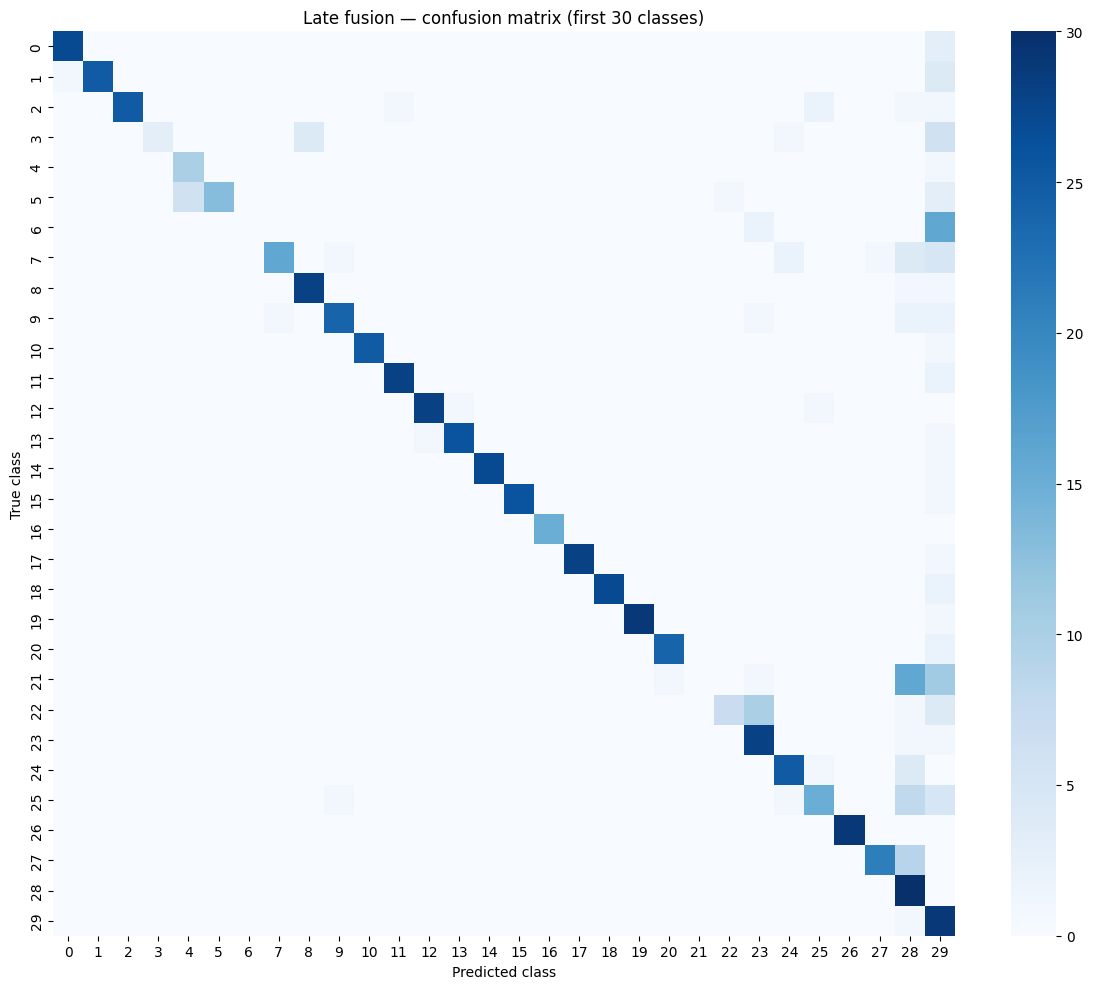

In [ ]:
# Final test evaluation — late fusion
ckpt = torch.load(LATE_CKPT, map_location=DEVICE)
late_model.load_state_dict(ckpt["model_state"])
_, late_acc, late_preds, late_labels = evaluate(late_model, test_loader, DEVICE)
late_topk = top_k_accuracy(late_model, test_loader, DEVICE)

print(f"Late fusion — Top-1: {late_topk[1]:.2f}%  Top-3: {late_topk[3]:.2f}%  Top-5: {late_topk[5]:.2f}%")

SHOW_N = 30
mask = np.array(late_labels) < SHOW_N
cm = confusion_matrix(
    np.array(late_labels)[mask],
    np.clip(np.array(late_preds)[mask], 0, SHOW_N - 1),
    labels=list(range(SHOW_N)),
)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Late fusion — confusion matrix (first 30 classes)")
plt.tight_layout()
plt.show()


In [ ]:
class EarlyFusionBirdClassifier(nn.Module):
    """Early fusion (Net1): image and spectrogram are concatenated along
    the channel dimension into a 6-channel input, processed by a single
    ResNet-50 with a modified first convolution.

    Parameters
    ----------
    num_classes : int
        Number of output classes.
    pretrained : bool
        Whether to use ImageNet-pretrained weights.

    Example
    -------
    >>> model = EarlyFusionBirdClassifier(num_classes=199)
    >>> logits = model(image_batch, spec_batch)  # shape: [B, 199]
    """

    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet50(weights=weights)

        old_conv = backbone.conv1
        new_conv = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight  # image channels
            new_conv.weight[:, 3:] = old_conv.weight  # spec channels

        backbone.conv1 = new_conv
        backbone.fc = nn.Linear(2048, num_classes)
        self.net = backbone

    def forward(self, image, spec):
        return self.net(torch.cat([image, spec], dim=1))


early_model = EarlyFusionBirdClassifier(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
print(f"Early fusion — params: {sum(p.numel() for p in early_model.parameters() if p.requires_grad) / 1e6:.1f}M")


Early fusion — params: 23.9M


In [ ]:
if os.path.exists(EARLY_CKPT):
    ckpt = torch.load(EARLY_CKPT, map_location=DEVICE)
    early_model.load_state_dict(ckpt["model_state"])
    early_model.eval()
    print(f"Loaded early fusion (epoch {ckpt['epoch']}, val acc={ckpt['accuracy'] * 100:.2f}%)")
    early_history = ckpt.get("history", None)
    early_best = ckpt["accuracy"]
else:
    print("No checkpoint found — training from scratch")
    early_history, early_best = run_training(early_model, "Early fusion", EARLY_CKPT)


Loaded early fusion (epoch 29, val acc=79.63%)


Early fusion — Top-1: 77.42%  Top-3: 90.44%  Top-5: 93.77%


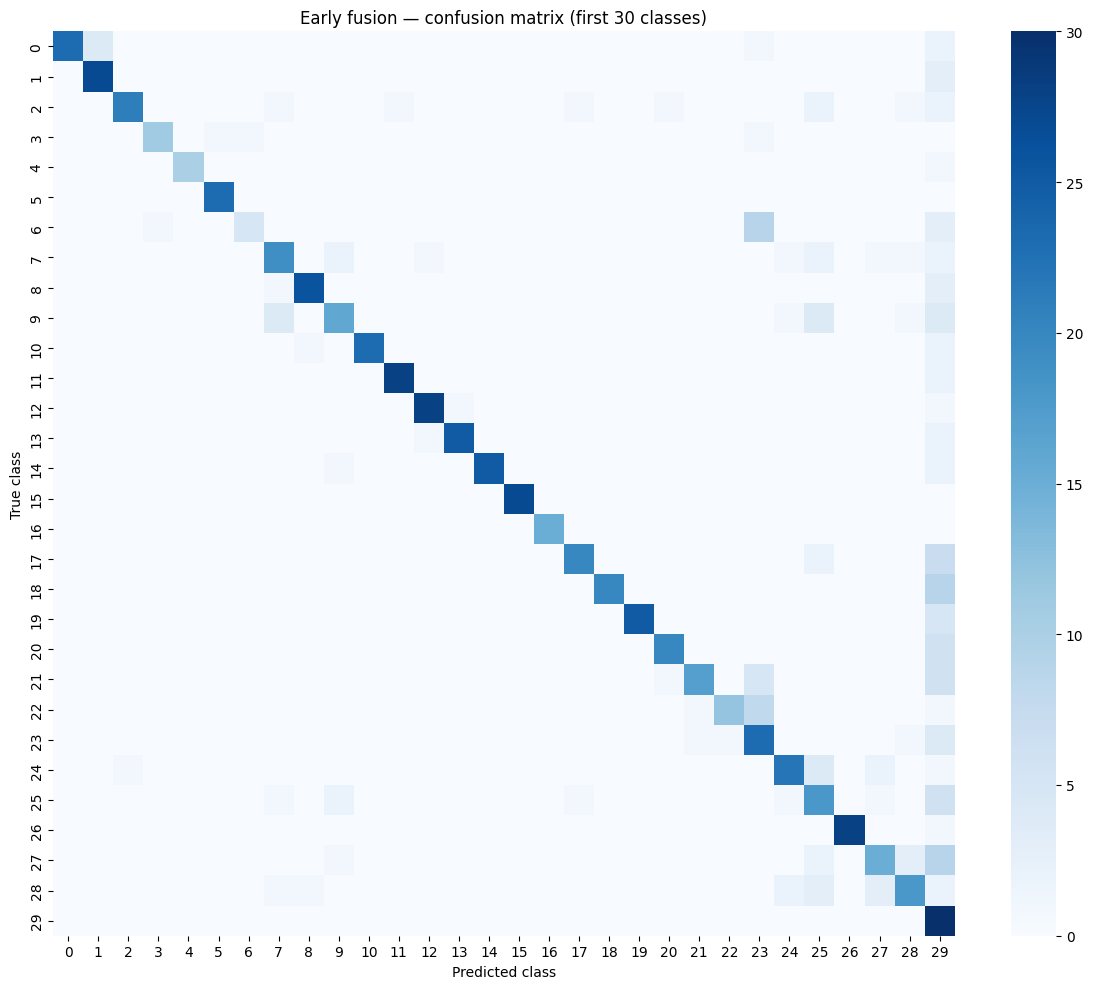

In [ ]:
# Final test evaluation for early fusion
ckpt = torch.load(EARLY_CKPT, map_location=DEVICE)
early_model.load_state_dict(ckpt["model_state"])
_, early_acc, early_preds, early_labels_list = evaluate(early_model, test_loader, DEVICE)
early_topk = top_k_accuracy(early_model, test_loader, DEVICE)

print(f"Early fusion — Top-1: {early_topk[1]:.2f}%  Top-3: {early_topk[3]:.2f}%  Top-5: {early_topk[5]:.2f}%")

SHOW_N = 30
mask = np.array(early_labels_list) < SHOW_N
cm = confusion_matrix(
    np.array(early_labels_list)[mask],
    np.clip(np.array(early_preds)[mask], 0, SHOW_N - 1),
    labels=list(range(SHOW_N)),
)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Early fusion — confusion matrix (first 30 classes)")
plt.tight_layout()
plt.show()


In [ ]:
class MiddleFusionBirdClassifier(nn.Module):
    """Middle fusion (Net2): two ResNet-50 backbones extract 2048-dim
    embeddings, which are concatenated and passed through a classifier head.

    Parameters
    ----------
    num_classes : int
        Number of output classes.
    pretrained : bool
        Whether to use ImageNet-pretrained weights.

    Example
    -------
    >>> model = MiddleFusionBirdClassifier(num_classes=199)
    >>> logits = model(image_batch, spec_batch)  # shape: [B, 199]
    """

    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None

        def make_backbone():
            net = models.resnet50(weights=weights)
            net.fc = nn.Identity()  # output: 2048-dim feature vector
            return net

        self.image_cnn = make_backbone()
        self.spec_cnn = make_backbone()
        self.classifier = nn.Sequential(
            nn.Linear(4096, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, num_classes),
        )

    def forward(self, image, spec):
        feats = torch.cat([self.image_cnn(image), self.spec_cnn(spec)], dim=1)
        return self.classifier(feats)


middle_model = MiddleFusionBirdClassifier(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
print(f"Middle fusion — params: {sum(p.numel() for p in middle_model.parameters() if p.requires_grad) / 1e6:.1f}M")


Middle fusion — params: 51.4M


In [ ]:
if os.path.exists(MIDDLE_CKPT):
    ckpt = torch.load(MIDDLE_CKPT, map_location=DEVICE)
    middle_model.load_state_dict(ckpt["model_state"])
    middle_model.eval()
    print(f"Loaded middle fusion (epoch {ckpt['epoch']}, val acc={ckpt['accuracy'] * 100:.2f}%)")
    middle_history = ckpt.get("history", None)
    middle_best = ckpt["accuracy"]
else:
    print("No checkpoint found — training from scratch")
    middle_history, middle_best = run_training(middle_model, "Middle fusion", MIDDLE_CKPT)


Loaded middle fusion (epoch 30, val acc=89.44%)


Middle fusion — Top-1: 75.65%  Top-3: 89.73%  Top-5: 93.41%


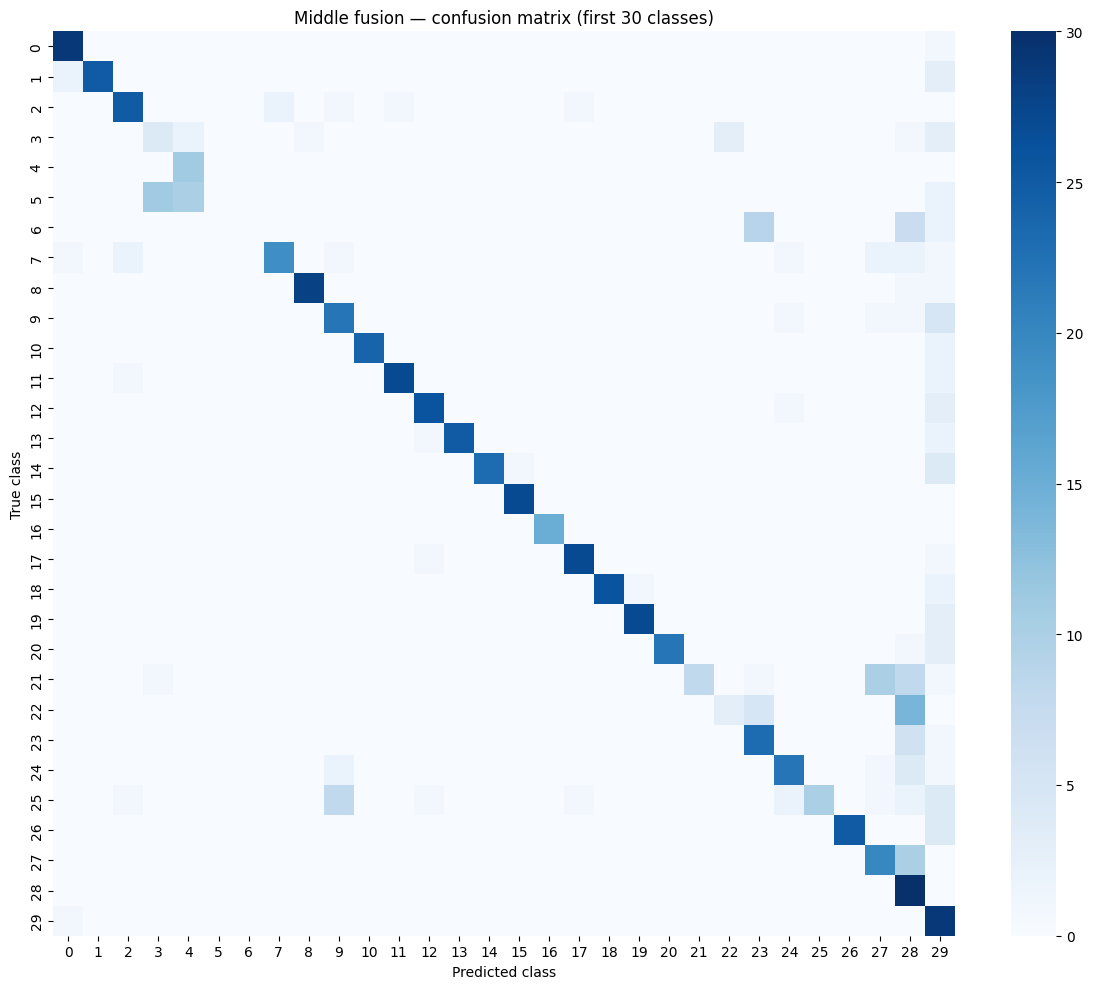

In [ ]:
# Final test evaluation for middle fusion
ckpt = torch.load(MIDDLE_CKPT, map_location=DEVICE)
middle_model.load_state_dict(ckpt["model_state"])
_, middle_acc, middle_preds, middle_labels_list = evaluate(middle_model, test_loader, DEVICE)
middle_topk = top_k_accuracy(middle_model, test_loader, DEVICE)

print(f"Middle fusion — Top-1: {middle_topk[1]:.2f}%  Top-3: {middle_topk[3]:.2f}%  Top-5: {middle_topk[5]:.2f}%")

SHOW_N = 30
mask = np.array(middle_labels_list) < SHOW_N
cm = confusion_matrix(
    np.array(middle_labels_list)[mask],
    np.clip(np.array(middle_preds)[mask], 0, SHOW_N - 1),
    labels=list(range(SHOW_N)),
)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Middle fusion — confusion matrix (first 30 classes)")
plt.tight_layout()
plt.show()


In [ ]:
class UnimodalDataset(Dataset):
    """Wrapper that extracts a single modality from a MultimodalBirdDataset.

    Parameters
    ----------
    multimodal_ds : MultimodalBirdDataset
        Source dataset.
    modality : str
        Either 'image' or 'spec'.

    Returns
    -------
    tuple of (torch.Tensor, int)
        (input_tensor, label)

    Example
    -------
    >>> uni_ds = UnimodalDataset(train_ds, 'image')
    >>> img, label = uni_ds[0]
    """

    def __init__(self, multimodal_ds, modality):
        assert modality in ("image", "spec")
        self.ds = multimodal_ds
        self.modality = modality

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, spec, label = self.ds[idx]
        return (image if self.modality == "image" else spec), label


def train_unimodal(modality, num_classes, ckpt_path, num_epochs=30):
    """Train a single-modality ResNet-50 baseline.

    Selects best checkpoint based on validation accuracy.

    Parameters
    ----------
    modality : str
        'image' or 'spec'.
    num_classes : int
        Number of output classes.
    ckpt_path : str
        Path to save/load best checkpoint.
    num_epochs : int
        Training epochs.

    Returns
    -------
    float
        Best validation accuracy.

    Example
    -------
    >>> val_acc = train_unimodal('image', 199, 'img.pth', num_epochs=30)
    """
    print(f"\n{'=' * 50}\nUnimodal baseline: {modality.upper()}\n{'=' * 50}")

    if os.path.exists(ckpt_path):
        uni_model = models.resnet50(weights=None)
        uni_model.fc = nn.Linear(2048, num_classes)
        uni_model = uni_model.to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        uni_model.load_state_dict(ckpt["model_state"])
        print(f"Loaded from {ckpt_path}  (val acc={ckpt['accuracy'] * 100:.2f}%)")
        return ckpt["accuracy"]

    uni_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    uni_model.fc = nn.Linear(2048, num_classes)
    uni_model = uni_model.to(DEVICE)
    uni_opt = optim.Adam(uni_model.parameters(), lr=1e-4, weight_decay=1e-4)

    train_dl = DataLoader(
        UnimodalDataset(train_ds, modality),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
    )
    val_dl = DataLoader(
        UnimodalDataset(val_ds, modality),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    )
    best_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        uni_model.train()
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(uni_model(x), y)
            uni_opt.zero_grad()
            loss.backward()
            uni_opt.step()

        uni_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_dl:
                preds = uni_model(x.to(DEVICE)).argmax(1)
                correct += (preds == y.to(DEVICE)).sum().item()
                total += y.size(0)
        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            torch.save({"model_state": uni_model.state_dict(),
                        "accuracy": best_acc}, ckpt_path)
            print(f"Epoch {epoch:2d}: val acc = {acc * 100:.2f}% saved")
        else:
            print(f"Epoch {epoch:2d}: val acc = {acc * 100:.2f}%")

    print(f"\nBest {modality} val accuracy: {best_acc * 100:.2f}%")
    return best_acc


def eval_unimodal_on_test(modality, num_classes, ckpt_path):
    """Load best unimodal checkpoint and evaluate on the test set.

    Parameters
    ----------
    modality : str
        'image' or 'spec'.
    num_classes : int
        Number of output classes.
    ckpt_path : str
        Path to the saved checkpoint.

    Returns
    -------
    float
        Test accuracy.

    Example
    -------
    >>> test_acc = eval_unimodal_on_test('image', 199, 'img.pth')
    """
    uni_model = models.resnet50(weights=None)
    uni_model.fc = nn.Linear(2048, num_classes)
    uni_model = uni_model.to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    uni_model.load_state_dict(ckpt["model_state"])
    uni_model.eval()
    test_dl = DataLoader(
        UnimodalDataset(test_ds, modality),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
    )
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_dl:
            preds = uni_model(x.to(DEVICE)).argmax(1)
            correct += (preds == y.to(DEVICE)).sum().item()
            total += y.size(0)
    acc = correct / total
    print(f"Unimodal {modality} TEST acc: {acc * 100:.2f}%")
    return acc


# Train (or load) unimodal baselines, then evaluate on test
train_unimodal("image", NUM_CLASSES, IMG_CKPT, num_epochs=30)
train_unimodal("spec", NUM_CLASSES, SPEC_CKPT, num_epochs=30)

img_acc = eval_unimodal_on_test("image", NUM_CLASSES, IMG_CKPT)
spec_acc = eval_unimodal_on_test("spec", NUM_CLASSES, SPEC_CKPT)



Unimodal baseline: IMAGE
Loaded from ./models/unimodal_image_best.pth  (val acc=71.67%)

Unimodal baseline: SPEC
Loaded from ./models/unimodal_spec_best.pth  (val acc=72.17%)
Unimodal image TEST acc: 70.57%
Unimodal spec TEST acc: 38.33%



## **Confusion matrices for each fusion model**
| Early Fusion | Middle Fusion| Late Fusion |
|---------|---------|---------|
| ![Confusion Matrix 1](https://drive.google.com/uc?export=view&id=1_N_q4YBTprkKSMHj80MnbWNmr2uZWWQ2) | ![Confusion Matrix 2](https://drive.google.com/uc?export=view&id=1F5A38RyQ8HEt-CxwxoUngAaz0yjkUTLr) | ![Confusion Matrix 3](https://drive.google.com/uc?export=view&id=100dh7e_e_ala7Ao7ZkCme6hd9STgZUEy) |


### Summary of Results
All metrics below are computed on the held-out **test set**, which was never used for model selection or hyperparameter tuning.


In [ ]:
print(f"\n{'=' * 68}")
print(f"{'Method':<30} {'Top-1':>8} {'Top-3':>8} {'Top-5':>8}")
print('=' * 68)
print(f"{'Image only (unimodal)':<30} {img_acc * 100:>7.2f}%  {'—':>7}  {'—':>7}")
print(f"{'Spectrogram only (unimodal)':<30} {spec_acc * 100:>7.2f}%  {'—':>7}  {'—':>7}")
print(f"{'Early fusion':<30} {early_topk[1]:>7.2f}%  {early_topk[3]:>7.2f}%  {early_topk[5]:>7.2f}%")
print(f"{'Middle fusion':<30} {middle_topk[1]:>7.2f}%  {middle_topk[3]:>7.2f}%  {middle_topk[5]:>7.2f}%")
print(f"{'Late fusion':<30} {late_topk[1]:>7.2f}%  {late_topk[3]:>7.2f}%  {late_topk[5]:>7.2f}%")
print('=' * 68)


Method                            Top-1    Top-3    Top-5
Image only (unimodal)            70.57%        —        —
Spectrogram only (unimodal)      38.33%        —        —
Early fusion                     77.42%    90.44%    93.77%
Middle fusion                    75.65%    89.73%    93.41%
Late fusion                      83.16%    93.43%    95.77%


## **Top-K accuracies**
The ouput from my run:
| Method                       | Top-1  | Top-3  | Top-5  |
|-----------------------------|--------|--------|--------|
| Image only (unimodal)       | 70.57% | —      | —      |
| Spectrogram only (unimodal) | 38.33% | —      | —      |
| Early fusion                | 77.42% | 90.44% | 93.77% |
| Middle fusion               | 75.65% | 89.73% | 93.41% |
| Late fusion                 | 83.16% | 93.43% | 95.77% |

In [ ]:
histories, names = [], []
for hist, name in [
    (late_history, "Late fusion"),
    (early_history, "Early fusion"),
    (middle_history, "Middle fusion"),
]:
    if hist is not None:
        histories.append(hist)
        names.append(name)

if histories:
    plot_history(histories, names, "Fusion strategy comparison")
else:
    print("All models were loaded from checkpoints, no training history to plot.")
    print("Delete checkpoints and re-run to generate learning curves.")


All models were loaded from checkpoints — no training history to plot.
Delete checkpoints and re-run to generate learning curves.


### 5.3 Discussion

All three fusion strategies outperform both unimodal baselines, with late fusion achieving the best results across all Top-K metrics. The gap between Top-1 and Top-5 accuracy (83.16% to 95.77%) suggests that even when the model's top prediction is wrong, the correct species is typically within its top 5 candidates, a desirable property for a practical identification system.

#### Comparison with the Original Study

The table below compares the results of this project with the original study by Naranchimeg et al. [5]:

| Method | Original study | Mine |
|--------|-------------------|------|
| Image only | 16.2% | 70.57% |
| Spectrogram only | 46.4% | 38.33% |
| Early fusion (Net1) | 50.0% | 77.42% |
| Middle fusion (Net2) | 49.9% | 75.65% |
| Late fusion (Net3, summation) | 53.8% | 83.16% |

Several observations emerge from this comparison:

The most striking difference is the image-only performance, my unimodal model scored an accuracy of 70.57% while the study's scored 16.2%. The original study trained CaffeNet from scratch, which is a relatively shallow architecture (5 convolutional layers) with random initialization. My project uses ResNet-50 [7] pretrained on ImageNet, which provides 50 layers of learned visual features and residual connections that avoid vanishing gradients. The pretrained features transfer well to fine-grained bird recognition, explaining the ~54 percentage point improvement.

Counterintuitively, the original study achieved a 46.4% spectrogram-only accuracy despite having a smaller dataset (4,807 vs. 9,270 spectrograms). Several factors likely explain this:

1. The original study did not use a validation set, they trained and evaluated directly on the test set. With only ~25 spectrograms per species on average and no early stopping based on held-out data, the model likely overfitted to the test spectrograms, producing an inflated accuracy. In this project, checkpoint selection is performed on a separate validation set, meaning the reported test accuracy reflects true generalization.
2. During the collection of spectrograms from Xeno-Canto and eBird, a significant number of recordings were found to contain background noise from other species, wind, rain, or human activity. Some recordings were also mislabeled or contained very faint vocalizations buried in ambient sound. While manual inspection and preprocessing (silence trimming, frequency filtering) addressed the worst cases, the resulting dataset is noisier than a carefully curated private collection. The original authors had the advantage of hand-selecting recordings, whereas scraping public repositories at scale inevitably introduces quality variation.
3. It may also be possible that a smaller dataset can yield higher test accuracy when the model memorizes it. With ~25 spectrograms per species split 50/50, the original study's audio CNN only needed to distinguish among ~12 test spectrograms per species, a much easier task than generalizing across the 47 spectrograms per species (on average) in this project's dataset.

#### Fusion results
Despite the differences in backbone, dataset size, and training procedure, the relative ranking of fusion strategies is identical: late > early > middle. This project's late fusion (83.16%) surpasses even the original study's best result with two-stage fine-tuning (78.9%), without requiring the more complex training procedure. This improvement is primarily driven by the stronger image backbone (ResNet-50 vs. CaffeNet) and a larger dataset.

The results demonstrate that the choice of backbone and pretraining has a larger impact on absolute performance than the fusion strategy itself. However, the consistent ranking of fusion strategies across two independent studies, with different architectures, datasets, and training procedures, provides strong evidence that late fusion is the most effective approach for combining visual and auditory modalities in bird classification.

#### Late Fusion - Best Model

Late fusion achieves the highest accuracy (83.16%) because it allows each stream to learn modality-specific features without interference. The image ResNet-50 can focus entirely on visual features (plumage patterns, beak shape, body proportions), while the spectrogram ResNet-50 can focus on auditory features (call frequency, temporal patterns, harmonic structure). Their independent logits are summed at the output, meaning the final prediction benefits from both modalities without either one being forced to compromise during feature learning.

Early and middle fusion force the network to learn joint representations earlier in the pipeline, which can cause the dominant modality (images, at 70.57%) to overshadow the weaker one (spectrograms, at 38.33%). This is consistent with the original study's observation that early and middle fusion filters tend to resemble the dominant modality's features [5].

#### Early Fusion vs. Middle Fusion

Early fusion outperforms middle fusion in this project (77.42% vs. 75.65%), which differs slightly from the original study where both performed nearly identically (50.0% vs. 49.9%). This may be because the channel-wise concatenation approach used here, where pretrained ImageNet weights are duplicated across both channel groups, provides a stronger initialization than the spatial concatenation used in the original study. This allows the single backbone to leverage pretrained features for both modalities from the start, whereas middle fusion must learn to combine two separate 2048-dimensional embeddings through an additional classifier head (4096 -> 1024 -> 199), introducing more parameters that need to be learned from scratch.

#### The Role of the Audio Modality

The spectrogram-only baseline (38.33%) is substantially lower than the image-only baseline (70.57%). This gap reflects multiple challenges:

- The spectrogram dataset (9,270 samples) is smaller than the image dataset (11,730), providing fewer training examples per species.
- Spectrogram counts per species range from 2 to 142. Species with very few spectrograms have insufficient variation for the model to learn robust auditory features.
- Many bird species share similar frequency ranges in their vocalizations, and spectrograms of different species can appear visually similar. Unlike photographs, which capture species-specific visual features (color, shape, markings), spectrograms are more abstract and require the CNN to learn subtle spectro-temporal patterns.
- Public audio repositories contain recordings of highly variable quality. Background noise from other species, wind, rain, traffic, and human activity contaminates many recordings. Some recordings also contain only faint or partial vocalizations. While preprocessing (silence trimming, frequency filtering to 0-10 kHz) mitigates the worst cases, the model must still learn to be robust to substantial noise.

Despite these challenges, adding the audio stream to the image stream improves accuracy by +12.6% (70.57% to 83.16%). This demonstrates that even a noisy, imbalanced audio signal provides complementary information that the image stream alone cannot capture. For instance, species that are visually similar but have distinct calls, or species that are partially occluded in photographs, benefit from the additional modality.

#### Training Dynamics

The figure below shows validation accuracy over training epochs for the middle fusion model compared to the unimodal image baseline. The multimodal model consistently outperforms the unimodal baseline throughout training, and both curves plateau without significant divergence between training and validation accuracy, suggesting that overfitting is not a major issue at the chosen number of epochs.

![Validation accuracy comparison](https://drive.google.com/uc?export=view&id=10lFIsqjYOmm7L1dcy2lJw10dRCpOLwb3)

*Figure 6: Validation accuracy over training epochs*

## **6 Conclusions**

This project demonstrates that multimodal fusion of bird images and audio spectrograms improves classification accuracy over single-modality baselines. The key findings are as follows.

Late fusion is the best strategy, achieving 83.16% Top-1 accuracy on 199 species, a +12.6% improvement over image-only (70.57%) and +44.8% over spectrogram-only (38.33%). All three fusion strategies outperform the unimodal baselines, confirming that the two modalities provide complementary information even when one modality (audio) is substantially weaker on its own. The ranking of fusion strategies (late > early > middle) is consistent with the original study by Naranchimeg et al. [5], suggesting this result generalizes across CNN architectures.

Beyond the classification results, a key contribution of this project is the public release of a spectrogram dataset aligned with CUB-200-2011, the first of its kind. The original study [5] relied on a privately collected audio dataset that was never published, making their work impossible to reproduce. The dataset constructed here (9,270 spectrograms, 199 species) was independently collected from Xeno-Canto and eBird, preprocessed, labeled, and published on Kaggle, enabling other researchers to reproduce and extend this work.

The spectrogram dataset, while nearly twice the size of the original study's, still averages ~47 spectrograms per species with notable class imbalance (ranging from 2 to 142 per species). Using unweighted `CrossEntropyLoss` means the model may underperform on species with fewer audio samples. The audio preprocessing pipeline (STFT, silence cropping) was kept simple; more advanced techniques such as mel-spectrograms or learned audio features could improve the audio stream's individual performance. Additionally, the validation set reuses training spectrograms (though not training images), which could introduce a slight optimistic bias in validation metrics, however, the final test metrics use fully separate data. Finally, the multiplication-based late fusion variant and the two-stage fine-tuning procedure from the original paper were not explored, and could yield further gains.

Future work could include expanding the audio dataset with additional sources beyond Xeno-Canto, applying class-weighted loss to address spectrogram imbalance, experimenting with attention-based fusion mechanisms, and extending the framework to other fine-grained classification tasks beyond birds.


## **References**

[1] N. Zhang, J. Donahue, R. Girshick, and T. Darrell, "Part-based R-CNNs for fine-grained category detection," *European Conference on Computer Vision*, pp. 834-849, 2014.

[2] S. Branson, G. Van Horn, S. Belongie, and P. Perona, "Bird species categorization using pose normalized deep convolutional nets," *arXiv preprint arXiv:1406.2952*, 2014.

[3] S. Kahl et al., "Large-scale bird sound classification using convolutional neural networks," *Working notes of CLEF*, 2017.

[4] E. Cakir et al., "Convolutional recurrent neural networks for bird audio detection," *25th European Signal Processing Conference (EUSIPCO)*, pp. 1744-1748, 2017.

[5] B. Naranchimeg, C. Zhang, and T. Akashi, "Cross-domain deep feature combination for bird species classification with audio-visual data," *arXiv preprint arXiv:1811.10199*, 2018.

[6] C. Wah, S. Branson, P. Welinder, P. Perona, and S. Belongie, "The Caltech-UCSD Birds-200-2011 dataset," *Tech. Rep. CNS-TR-2011-001*, California Institute of Technology, 2011.

[7] K. He, X. Zhang, S. Ren, and J. Sun, "Deep residual learning for image recognition," *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, pp. 770-778, 2016.
